In [2]:
# project setup
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

In [3]:
# DATA ACQUISITION
nea = pd.read_csv("../data/near_earth_asteroids_2025 (1).csv")
ca  = pd.read_csv("../data/asteroid_close_approaches_2015_2035 (1).csv")

print(f"near-earth asteroids: {nea.shape[0]:,} rows × {nea.shape[1]} cols")
print(f"close approaches: {ca.shape[0]:,} rows × {ca.shape[1]} cols")

ca_agg = (
    ca.groupby("designation")
    .agg(
        n_approaches = ("dist_km", "count"),
        min_dist_km = ("dist_km", "min"),
        mean_dist_km = ("dist_km", "mean"),
        min_dist_lunar = ("dist_lunar", "min"),
        max_velocity_ks = ("velocity_km_s", "max"),
        mean_velocity_ks = ("velocity_km_s", "mean"),
    )
    .reset_index()
    .rename(columns={"designation": "pdes"})
)

nea["pdes_str"] = nea["pdes"].astype(str).str.strip()
ca_agg["pdes"] = ca_agg["pdes"].astype(str).str.strip()

df = nea.merge(ca_agg, left_on="pdes_str", right_on="pdes", how="left")
print(f"after merge: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"PHA distribution: {df['pha'].value_counts().to_dict()}")

near-earth asteroids: 41,281 rows × 29 cols
close approaches: 27,430 rows × 13 cols
after merge: 41,281 rows × 37 cols
PHA distribution: {False: 38742, True: 2539}


In [4]:
# DATA CLEANING and feature selection
# delete MOID as it directly defines PHA (<=0.05)
# delete H - magnitude (H <= 22 for PHA)
feature_cols = [
    "e",            # orbital eccentricity
    "a",            # semi-major axis
    "i",            # inclination
    "q",            # perihelion distance
    "ad",           # aphelion distance
    "per_y",        # orbital period in years
    "data_arc_years",
    # close-approach aggregate stats (actual observed geometry)
    "n_approaches",
    "mean_dist_km",
    "max_velocity_ks",
    "mean_velocity_ks",
]

target_col = "pha"
df_model = df[feature_cols + [target_col]].copy()
df_model[target_col] = df_model[target_col].astype(int)

missing_before = df_model.isnull().sum()
for col in feature_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())
missing_after = df_model.isnull().sum()
print(f"missing values before imputation : {missing_before.sum()}")
print(f"missing values after imputation : {missing_after.sum()}")

X = df_model[feature_cols].values
y = df_model[target_col].values
print(f"feature matrix shape : {X.shape}")
print(f"class balance  (0/1) : {(y==0).sum():,} / {(y==1).sum():,}  "
      f"({(y==1).mean()*100:.1f}% hazardous)")

missing values before imputation : 82010
missing values after imputation : 0
feature matrix shape : (41281, 11)
class balance  (0/1) : 38,742 / 2,539  (6.2% hazardous)


In [5]:
# CORRELATION AND FEATURE SELECTION
corr_df = pd.DataFrame(X, columns=feature_cols)
corr_matrix = corr_df.corr()

# drop cols with correlation>0.95 to reduce multicollin
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col].abs() > 0.95)]
print(f"dropping highly correlated features (>0.95): {to_drop}")

selected_features = [f for f in feature_cols if f not in to_drop]
X = corr_df[selected_features].values
print(f"features kept: {len(selected_features)}  →  {selected_features}")

dropping highly correlated features (>0.95): ['ad', 'per_y', 'mean_velocity_ks']
features kept: 8  →  ['e', 'a', 'i', 'q', 'data_arc_years', 'n_approaches', 'mean_dist_km', 'max_velocity_ks']


In [6]:
scaler_vis = StandardScaler()
X_scaled   = scaler_vis.fit_transform(X)
pca        = PCA(n_components=2, random_state=42)
X_pca      = pca.fit_transform(X_scaled)
pca_var    = pca.explained_variance_ratio_
print(f"\nPCA (2 components) explained variance: "
      f"{pca_var[0]*100:.1f}% + {pca_var[1]*100:.1f}% = {pca_var.sum()*100:.1f}%")


PCA (2 components) explained variance: 22.8% + 16.3% = 39.1%


In [7]:
# Modelling - random forest + k fold
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",   # handles class imbalance
    random_state=42,
    n_jobs=-1,
)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", rf),
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    pipe, X, y,
    cv=skf,
    scoring=["accuracy", "f1", "roc_auc", "precision", "recall"],
    return_train_score=True,
    return_estimator=True,
)

metrics = {
    "Accuracy" : cv_results["test_accuracy"],
    "F1"       : cv_results["test_f1"],
    "ROC-AUC"  : cv_results["test_roc_auc"],
    "Precision": cv_results["test_precision"],
    "Recall"   : cv_results["test_recall"],
}

print(f"\n{'Metric':<12} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 48)
for name, vals in metrics.items():
    print(f"{name:<12} {vals.mean():>8.4f} {vals.std():>8.4f} "
          f"{vals.min():>8.4f} {vals.max():>8.4f}")


Metric           Mean      Std      Min      Max
------------------------------------------------
Accuracy       0.8771   0.0039   0.8694   0.8800
F1             0.4671   0.0082   0.4511   0.4745
ROC-AUC        0.9457   0.0038   0.9383   0.9495
Precision      0.3186   0.0072   0.3043   0.3236
Recall         0.8751   0.0097   0.8619   0.8898


In [8]:
# TESTING
*train_idx_list, (train_idx, test_idx) = list(skf.split(X, y))
best_pipe = cv_results["estimator"][-1]
X_test, y_test = X[test_idx], y[test_idx]

y_pred  = best_pipe.predict(X_test)
y_proba = best_pipe.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-PHA", "PHA"]))
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")

cm = confusion_matrix(y_test, y_pred)

# feature importances from fitted RF
rf_fitted   = best_pipe.named_steps["rf"]
importances = rf_fitted.feature_importances_
feat_imp_df = (
    pd.DataFrame({"feature": selected_features, "importance": importances})
    .sort_values("importance", ascending=False)
)


Classification Report:
              precision    recall  f1-score   support

     Non-PHA       0.99      0.88      0.93      7748
         PHA       0.32      0.89      0.47       508

    accuracy                           0.88      8256
   macro avg       0.66      0.88      0.70      8256
weighted avg       0.95      0.88      0.90      8256

ROC-AUC  : 0.9495


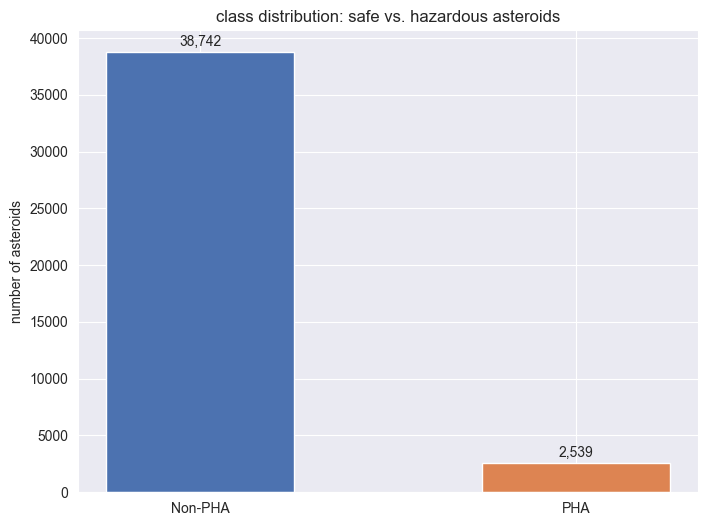

In [12]:
# plots
# 1. class distribution
plt.figure(figsize=(8, 6))
labels = ["Non-PHA", "PHA"]
counts = [(y==0).sum(), (y==1).sum()]
palette = {"Non-PHA": "#4c72b0", "PHA": "#dd8452"}

bars = plt.bar(labels, counts, color=list(palette.values()), edgecolor="white", width=0.5)
plt.title("class distribution: safe vs. hazardous asteroids")
plt.ylabel("number of asteroids")

for bar, cnt in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f"{cnt:,}", ha="center", va="bottom")
plt.show()

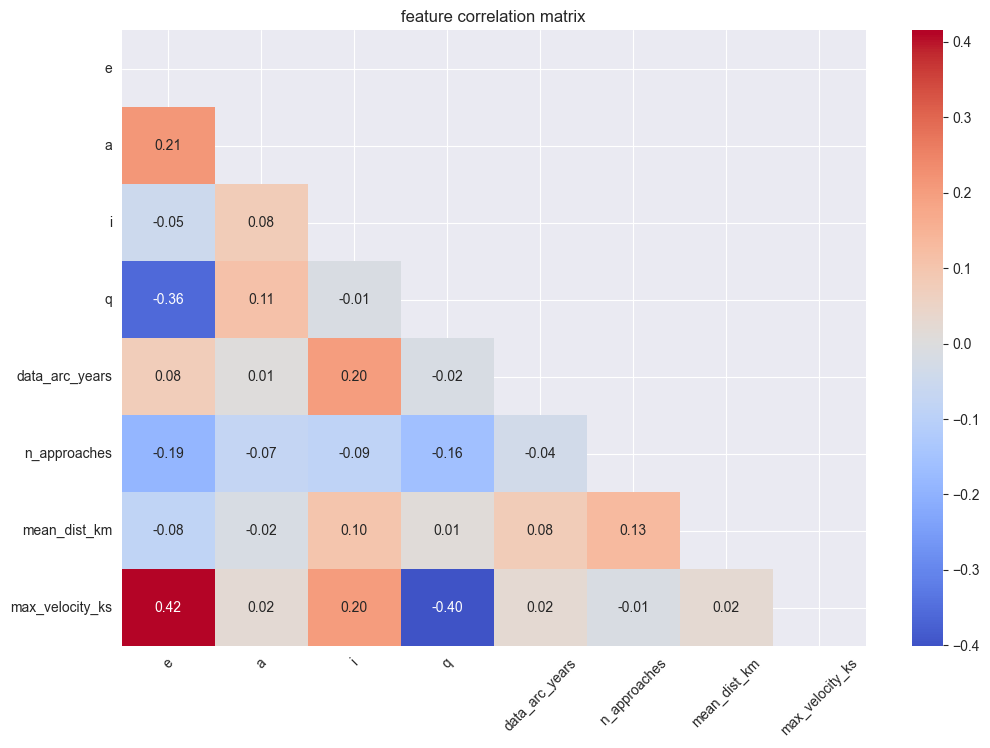

In [13]:
plt.figure(figsize=(12, 8))
corr_sel = pd.DataFrame(X, columns=selected_features).corr()
mask = np.triu(np.ones_like(corr_sel, dtype=bool))

sns.heatmap(corr_sel, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("feature correlation matrix")
plt.xticks(rotation=45)
plt.show()

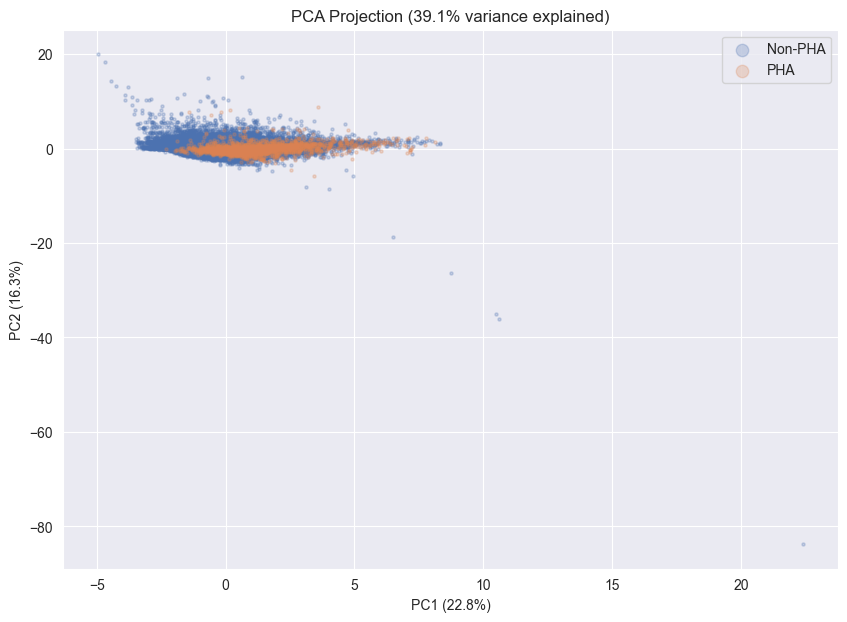

In [14]:
# PCA scatter
plt.figure(figsize=(10, 7))
labels = ["Non-PHA", "PHA"]
for label_idx, label_name, color in [(0, "Non-PHA", "#4c72b0"), (1, "PHA", "#dd8452")]:
    plt.scatter(X_pca[y==label_idx, 0], X_pca[y==label_idx, 1],
                c=color, alpha=0.25, s=5, label=label_name)

plt.title(f"PCA Projection ({pca_var.sum()*100:.1f}% variance explained)")
plt.xlabel(f"PC1 ({pca_var[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca_var[1]*100:.1f}%)")
plt.legend(markerscale=4)
plt.show()

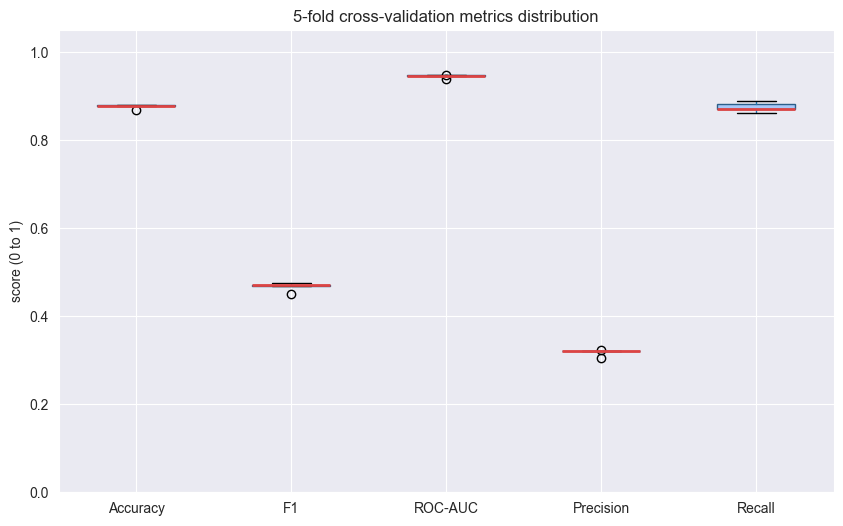

In [15]:
plt.figure(figsize=(10, 6))
metric_data = pd.DataFrame({k: v for k, v in metrics.items()})
metric_data.boxplot(patch_artist=True,
                    boxprops=dict(facecolor="#a8c8f8", color="#2c5f8a"),
                    medianprops=dict(color="#dd4444", linewidth=2))

plt.title("5-fold cross-validation metrics distribution")
plt.ylabel("score (0 to 1)")
plt.ylim(0, 1.05)
plt.show()

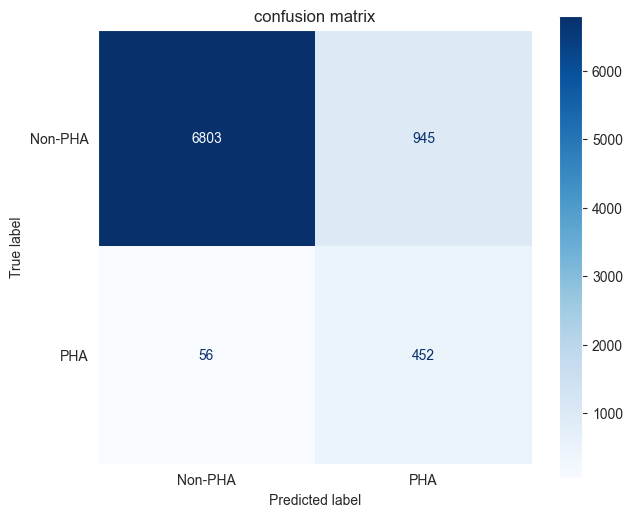

In [16]:
# confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=["Non-PHA", "PHA"]).plot(ax=ax, cmap="Blues")
plt.title("confusion matrix")
(plt.grid(False) )
plt.show()

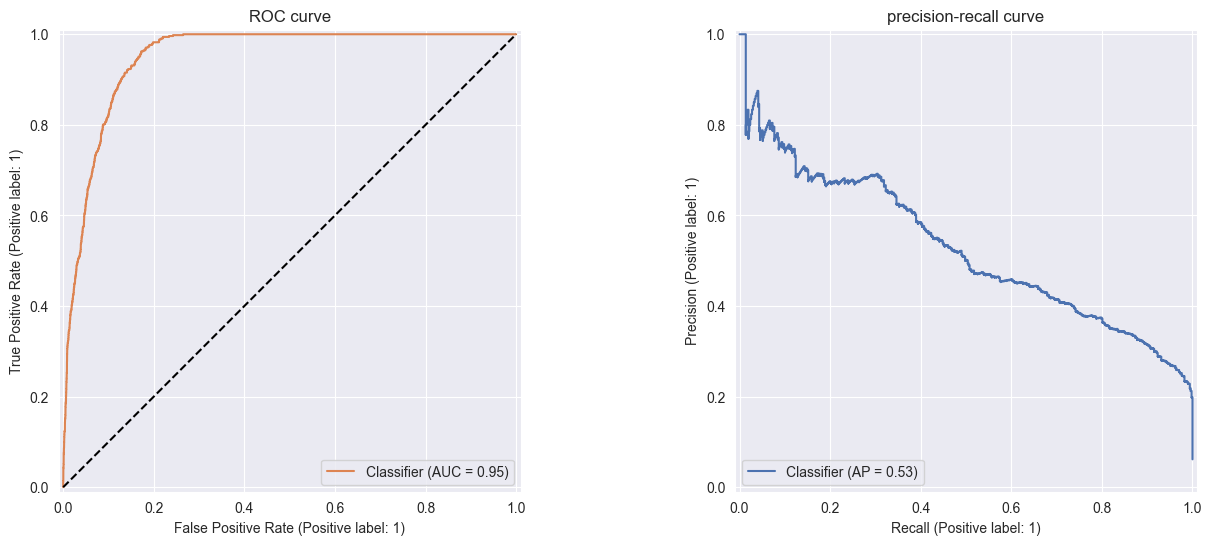

In [17]:
# ROC and precision recall
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax1, color="#dd8452")
ax1.plot([0,1],[0,1],"k--", label="random baseline")
ax1.set_title("ROC curve")

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=ax2, color="#4c72b0")
ax2.set_title("precision-recall curve")

plt.show()

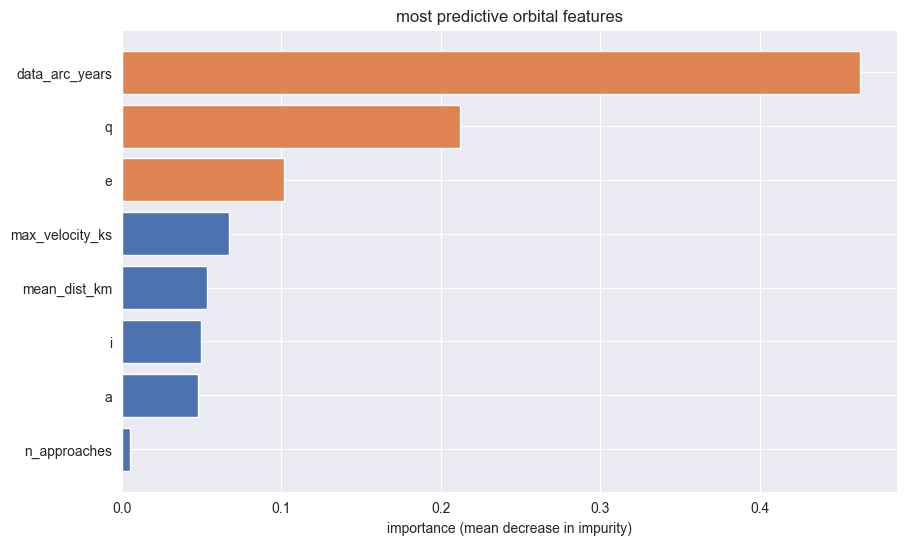

In [18]:
# feature importance
plt.figure(figsize=(10, 6))
top_n = feat_imp_df.head(10)

colors = ["#dd8452" if i < 3 else "#4c72b0" for i in range(len(top_n))]

plt.barh(top_n["feature"][::-1], top_n["importance"][::-1], color=colors[::-1])
plt.title("most predictive orbital features")
plt.xlabel("importance (mean decrease in impurity)")
plt.show()